# ADVANCED CRYPTO TRADING — LSTM + ATTENTION DEEP LEARNING SYSTEM

CONTEXTUAL ANCHOR — The Fusion Strategy & Fee Trap

## Our existing system:                                                      
1. Technical: XGBoost on RSI, Bollinger Bands, On-Chain data             
2. Sentiment: NLP score from news/social feeds                           
3. Execution: Only trade when fused confidence > 0.53  (fee trap guard)  
                                                                           
## This notebook REPLACES the XGBoost with an LSTM + Attention model that:  
   • Ingests 60-candle OHLCV sequences (time-series branch)                
   • Fuses Sentiment + On-Chain as static features (dense branch)          
   • Outputs class probabilities for Hold / Buy / Sell                     
   • Preserves the 0.53 confidence threshold logic                         
                                                                            
## KEY DESIGN DECISIONS:                                                     
   • Walk-Forward CV (never shuffle time-series data)                      
   • Augmentation on TRAIN ONLY (no data leakage)                          
   • Confidence histogram to re-calibrate the 0.53 threshold

# CELL 1 — Install & Import Dependencies

**We use:**

- tensorflow/keras  → Deep Learning model (LSTM + Attention)
- ta                → Technical indicators (RSI, Bollinger, MACD, ATR)
- yfinance          → Demo OHLCV download (swap with your broker feed)
- scikit-learn      → TimeSeriesSplit, metrics, scaler

In [3]:
!pip install ta yfinance --quiet

  Preparing metadata (setup.py) ... done


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
# ── TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [1]:
# ── Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

In [4]:
# ── Technical indicators + data
import ta
import yfinance as yf

In [8]:
# ── Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [9]:
# ── Global Trading Config (mirrors your Fusion strategy)
CONFIDENCE_THRESHOLD = 0.53   # Must beat trading fees — keep in sync with prod
SEQUENCE_LEN         = 60     # Last N candles fed into LSTM
N_FORWARD            = 3      # Predict return N candles ahead
BUY_THRESH           =  0.02  # +2% forward return  → Buy
SELL_THRESH          = -0.02  # -2% forward return  → Sell
CLASS_NAMES          = ['Hold', 'Buy', 'Sell']

print(f"   All imports successful")
print(f"   Confidence threshold : {CONFIDENCE_THRESHOLD}")
print(f"   Sequence length      : {SEQUENCE_LEN} candles")
print(f"   Prediction horizon   : {N_FORWARD} candles")

   All imports successful
   Confidence threshold : 0.53
   Sequence length      : 60 candles
   Prediction horizon   : 3 candles


# CELL 2 — Data Loading & Feature Engineering

**Steps:**
1. Download BTC-USD daily OHLCV via yfinance (replace with your live feed)
2. Compute technical indicators that mirror your XGBoost feature set:
     RSI, Bollinger Band Width/Position, MACD, ATR, OBV
3. Add simulated Sentiment & On-Chain scores (Replace these with your real NLP pipeline output in production)
4. Generate Buy / Sell / Hold labels from forward returns

In [10]:
# ── 2.1  Download OHLCV
print("Downloading BTC-USD daily data...")
raw = yf.download(
    'BTC-USD', start='2020-01-01', end='2024-12-31',
    interval='1d', progress=False
)
raw.columns = raw.columns.get_level_values(0)          # flatten multi-index
raw = raw[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
print(f"Loaded {len(raw)} candles  "
      f"({raw.index[0].date()} → {raw.index[-1].date()})")

Loaded 1826 candles  (2020-01-01 → 2024-12-30)


In [11]:
# ── 2.2  Technical Indicators
df = raw.copy()

# RSI (14)
df['rsi'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

# Bollinger Bands — width and % position within bands
bb = ta.volatility.BollingerBands(df['Close'], window=20, window_dev=2)
df['bb_width'] = (bb.bollinger_hband() - bb.bollinger_lband()) / bb.bollinger_mavg()
df['bb_pct']   = bb.bollinger_pband()

# MACD and signal line divergence
macd_ind        = ta.trend.MACD(df['Close'])
df['macd']      = macd_ind.macd()
df['macd_sig']  = macd_ind.macd_signal()
df['macd_diff'] = macd_ind.macd_diff()

# ATR — average true range (volatility proxy)
df['atr'] = ta.volatility.AverageTrueRange(
    df['High'], df['Low'], df['Close']
).average_true_range()

# OBV — on-balance volume (mirrors on-chain volume pressure)
df['obv'] = ta.volume.OnBalanceVolumeIndicator(
    df['Close'], df['Volume']
).on_balance_volume()

# Log returns
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

# Volume normalised by 20-day rolling mean
df['vol_ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()

In [12]:
# ── 2.3  Simulated Sentiment & On-Chain Scores
# In production: replace these 3 lines with your NLP pipeline merge
np.random.seed(SEED)
df['sentiment_score']          = np.clip(np.random.normal(0.0, 0.3,  len(df)), -1,  1)
df['onchain_addr_norm']        = np.clip(np.random.normal(0.5, 0.15, len(df)),  0,  1)
df['fear_greed_norm']          = np.clip(np.random.normal(50,  15,   len(df)),  0, 100) / 100


In [13]:
# ── 2.4  Label Generation
# Forward return over N_FORWARD candles — this is what we are predicting
df['fwd_return'] = df['Close'].shift(-N_FORWARD) / df['Close'] - 1
df['label'] = 0                                              # default: Hold
df.loc[df['fwd_return'] >  BUY_THRESH,  'label'] = 1        # Buy
df.loc[df['fwd_return'] <  SELL_THRESH, 'label'] = 2        # Sell

df.dropna(inplace=True)

print(f"\nDataset shape after feature engineering: {df.shape}")
print("\nLabel distribution:")
label_counts = df['label'].value_counts().rename({0:'Hold', 1:'Buy', 2:'Sell'})
print(label_counts)
print(f"\nClass balance: {(label_counts / label_counts.sum() * 100).round(1).to_dict()}")




Dataset shape after feature engineering: (1790, 20)

Label distribution:
label
Hold    669
Buy     618
Sell    503
Name: count, dtype: int64

Class balance: {'Hold': 37.4, 'Buy': 34.5, 'Sell': 28.1}


# CELL 3 — Feature Split: Time-Series vs Static

Our dual-input architecture requires two feature groups:

  - TIME-SERIES FEATURES  → fed into the LSTM branch (shape: [batch, 60, n_ts])
    OHLCV + technical indicators that change candle-by-candle

  - STATIC FEATURES       → fed into the Dense branch (shape: [batch, n_static])
    Sentiment score, on-chain metrics — slow-moving contextual signals

  - This mirrors the original Fusion design: TA model + NLP model → fused score

In [14]:
TS_FEATURES = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'rsi', 'bb_width', 'bb_pct',
    'macd', 'macd_sig', 'macd_diff',
    'atr', 'obv', 'log_return', 'vol_ratio'
]

In [15]:
STATIC_FEATURES = [
    'sentiment_score',
    'onchain_addr_norm',
    'fear_greed_norm'
]

In [16]:
print(f"Time-series features : {len(TS_FEATURES)}  → LSTM branch")
print(f"Static features      : {len(STATIC_FEATURES)}  → Dense branch")
print(f"Total features       : {len(TS_FEATURES) + len(STATIC_FEATURES)}")

Time-series features : 15  → LSTM branch
Static features      : 3  → Dense branch
Total features       : 18


# CELL 4 — Sequence Builder

Converts the flat dataframe into overlapping windows of SEQUENCE_LEN candles.
  - X_seq   : shape (n_samples, SEQUENCE_LEN, n_ts_features)
  - X_static: shape (n_samples, n_static_features)
  - y       : shape (n_samples,)
  
Each sample's static features are taken from the LAST candle of the window
(most recent sentiment reading at prediction time).

In [17]:
def build_sequences(dataframe, ts_cols, static_cols, label_col, seq_len):
    """
    Build rolling-window sequences from a time-ordered dataframe.

    Parameters
    ----------
    dataframe  : pd.DataFrame — full feature + label dataframe
    ts_cols    : list[str]    — columns for the LSTM time-series input
    static_cols: list[str]    — columns for the static dense input
    label_col  : str          — target column name
    seq_len    : int          — look-back window length

    Returns
    -------
    X_seq    : np.ndarray  shape (N, seq_len, len(ts_cols))
    X_static : np.ndarray  shape (N, len(static_cols))
    y        : np.ndarray  shape (N,)
    """
    ts_vals     = dataframe[ts_cols].values
    static_vals = dataframe[static_cols].values
    labels      = dataframe[label_col].values

    X_seq, X_static, y = [], [], []

    for i in range(seq_len, len(dataframe)):
        X_seq.append(ts_vals[i - seq_len : i])   # window of past candles
        X_static.append(static_vals[i])           # snapshot at prediction time
        y.append(labels[i])

    return (
        np.array(X_seq,    dtype=np.float32),
        np.array(X_static, dtype=np.float32),
        np.array(y,        dtype=np.int32)
    )


X_seq, X_static, y = build_sequences(df, TS_FEATURES, STATIC_FEATURES, 'label', SEQUENCE_LEN)

print(f"X_seq    shape : {X_seq.shape}   (samples, seq_len, ts_features)")
print(f"X_static shape : {X_static.shape}  (samples, static_features)")
print(f"y        shape : {y.shape}")

X_seq    shape : (1730, 60, 15)   (samples, seq_len, ts_features)
X_static shape : (1730, 3)  (samples, static_features)
y        shape : (1730,)


# CELL 5 — DataAugmenter Class  (TRAIN SET ONLY)

- **WHY AUGMENT?**
  
Financial data is scarce. Augmentation synthetically expands the training
  set to reduce overfitting to specific price patterns.
- **TECHNIQUES:**
  1. Gaussian Noise Injection
     Adds tiny random noise scaled to each feature's std.
     The model can no longer memorise exact price levels.
  2. Time Warping
     Interpolates the sequence on a slightly stretched/compressed time grid,
     simulating faster or slower market regimes.
    
SAFETY RULE: augment() is called ONLY on training data inside the
    walk-forward loop. Validation and test sets always use raw data.

In [18]:
class DataAugmenter:
    """
    Financial time-series augmentation for LSTM sequence data.

    Parameters
    ----------
    noise_std   : float — Gaussian noise magnitude (fraction of feature std)
    warp_sigma  : float — smoothness of the time-warp displacement curve
    warp_knots  : int   — number of random control points for warping
    aug_factor  : int   — how many augmented copies to create per original sample
    """

    def __init__(self, noise_std=0.005, warp_sigma=0.2, warp_knots=4, aug_factor=1):
        self.noise_std  = noise_std
        self.warp_sigma = warp_sigma
        self.warp_knots = warp_knots
        self.aug_factor = aug_factor

    # ── Technique 1: Gaussian Noise Injection ─────────────────────────────────
    def add_gaussian_noise(self, X):
        """
        Add feature-scaled Gaussian noise to every timestep.
        Noise is small enough to preserve the signal but large enough
        to prevent memorisation of exact price levels.
        """
        std_per_feature = X.std(axis=(0, 1), keepdims=True) + 1e-8
        noise = np.random.normal(0, self.noise_std, X.shape) * std_per_feature
        return (X + noise).astype(np.float32)

    # ── Technique 2: Time Warping ─────────────────────────────────────────────
    def time_warp(self, X):
        """
        Apply a smooth random warp to the time axis of each sequence.
        Stretching/compressing the timeline simulates different market tempos
        (e.g., a crash that happens over 2 days vs 5 days).
        """
        batch, seq_len, n_feat = X.shape
        warped = np.empty_like(X)

        for b in range(batch):
            # Build a smooth warp curve using random knots
            knot_x = np.linspace(0, seq_len - 1, self.warp_knots)
            knot_y = knot_x + np.random.normal(0, self.warp_sigma * seq_len,
                                                self.warp_knots)
            knot_y = np.clip(knot_y, 0, seq_len - 1)
            # Interpolate to a full-length warp map
            warp_map = np.interp(np.arange(seq_len), knot_x, knot_y)
            # Resample each feature along the warped timeline
            for f in range(n_feat):
                warped[b, :, f] = np.interp(
                    warp_map,
                    np.arange(seq_len),
                    X[b, :, f]
                )
        return warped.astype(np.float32)

    # ── Combined Augmentation ─────────────────────────────────────────────────
    def augment(self, X_seq, X_static, y):
        """
        Generate augmented copies of the training set.
        Static features (sentiment, on-chain) are preserved unchanged —
        augmentation only applies to the time-series sequences.

        Returns
        -------
        X_seq_aug, X_static_aug, y_aug — original + augmented samples combined
        """
        aug_seqs, aug_statics, aug_labels = [X_seq], [X_static], [y]

        for _ in range(self.aug_factor):
            # Randomly pick either noise or warp for each augmentation pass
            if np.random.rand() > 0.5:
                new_seq = self.add_gaussian_noise(X_seq.copy())
            else:
                new_seq = self.time_warp(X_seq.copy())

            aug_seqs.append(new_seq)
            aug_statics.append(X_static.copy())
            aug_labels.append(y.copy())

        return (
            np.concatenate(aug_seqs,    axis=0),
            np.concatenate(aug_statics, axis=0),
            np.concatenate(aug_labels,  axis=0)
        )


# Quick sanity check
_aug = DataAugmenter(aug_factor=1)
_s, _st, _y = _aug.augment(X_seq[:10], X_static[:10], y[:10])
print(f"Augmentation test — input: {X_seq[:10].shape}  →  output: {_s.shape}")
print("DataAugmenter class ready")


Augmentation test — input: (10, 60, 15)  →  output: (20, 60, 15)
DataAugmenter class ready


# CELL 6 — LSTM + Attention Model Architecture

WHY GRU + ATTENTION?
- GRU: Captures sequential dependencies in OHLCV candles
- Attention: Focuses on the MOST IMPORTANT candles in the window, (e.g., sudden volume spike or crash candle gets higher weight)
- Static branch: Preserves your NLP sentiment fusion logic

In [19]:
def build_model(seq_len, n_ts_features, n_static_features, n_classes=3,
                gru_units_1=128, gru_units_2=64,
                dense_static=32, dense_fused_1=128, dense_fused_2=64,
                dropout_1=0.3, dropout_2=0.2, learning_rate=1e-3):
    """
    Dual-input LSTM/GRU + Attention model.

    Parameters
    ----------
    seq_len            : int — length of the time-series window
    n_ts_features      : int — number of time-series features
    n_static_features  : int — number of static (sentiment/on-chain) features
    n_classes          : int — number of output classes (Hold/Buy/Sell)

    Returns
    -------
    keras.Model
    """

    # ── Input A: Time-series (OHLCV + technicals) ────────────────────────────
    ts_input = Input(shape=(seq_len, n_ts_features), name='ts_input')

    # First GRU layer — returns full sequence so attention can see all steps
    x = layers.GRU(gru_units_1, return_sequences=True,
                   recurrent_dropout=0.1, name='gru_1')(ts_input)
    x = layers.LayerNormalization()(x)

    # Second GRU layer — refines the representation
    x = layers.GRU(gru_units_2, return_sequences=True,
                   recurrent_dropout=0.1, name='gru_2')(x)
    x = layers.LayerNormalization()(x)

    # ── Attention Mechanism ───────────────────────────────────────────────────
    # Computes a score for each time-step → softmax → weighted sum
    # This lets the model "focus" on critical market moments (crash candle,
    # breakout bar, abnormal volume) instead of treating all candles equally.
    attn_scores = layers.Dense(1, activation='tanh', name='attn_score')(x)
    attn_weights = layers.Softmax(axis=1, name='attn_weights')(attn_scores)
    context = layers.Multiply(name='attn_context')([x, attn_weights])
    context = layers.Lambda(
        lambda t: tf.reduce_sum(t, axis=1), name='context_vector'
    )(context)

    # ── Input B: Static features (Sentiment + On-Chain) ──────────────────────
    static_input = Input(shape=(n_static_features,), name='static_input')
    s = layers.Dense(dense_static, activation='relu', name='static_dense')(static_input)
    s = layers.LayerNormalization()(s)

    # ── Fusion: Concatenate both branches ────────────────────────────────────
    # This is the equivalent of your existing "Fusion score" combining
    # technical analysis + sentiment signals.
    fused = layers.Concatenate(name='fusion')([context, s])

    # ── Classification Head ───────────────────────────────────────────────────
    z = layers.Dense(dense_fused_1, activation='relu', name='dense_1')(fused)
    z = layers.Dropout(dropout_1, name='dropout_1')(z)
    z = layers.Dense(dense_fused_2, activation='relu', name='dense_2')(z)
    z = layers.Dropout(dropout_2, name='dropout_2')(z)

    # Output: 3 classes — Hold(0), Buy(1), Sell(2)
    # Softmax produces calibrated probabilities for the 0.53 threshold
    output = layers.Dense(n_classes, activation='softmax', name='output')(z)

    model = Model(inputs=[ts_input, static_input], outputs=output, name='LSTM_Attention_Fusion')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ── Preview Architecture ──────────────────────────────────────────────────────
demo_model = build_model(
    seq_len=SEQUENCE_LEN,
    n_ts_features=len(TS_FEATURES),
    n_static_features=len(STATIC_FEATURES)
)
demo_model.summary()
print("\n Model architecture ready")

Model: "LSTM_Attention_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ts_input            │ (None, 60, 15)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 60, 128)   │     55,680 │ ts_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 128)   │        256 │ gru_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 60, 64)    │     37,248 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ gru_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_score (Dense)  │ (None, 60, 1)     │         65 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_weights        │ (None, 60, 1)     │          0 │ attn_score[0][0]  │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_context        │ (None, 60, 64)    │          0 │ layer_normalizat… │
│ (Multiply)          │                   │            │ attn_weights[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_dense        │ (None, 32)        │        128 │ static_input[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_vector      │ (None, 64)        │          0 │ attn_context[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32)        │         64 │ static_dense[0][… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 96)        │          0 │ context_vector[0… │
│ (Concatenate)       │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     12,416 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 114,436 (447.02 KB)

 Trainable params: 114,436 (447.02 KB)

 Non-trainable params: 0 (0.00 B)


 Model architecture ready


# CELL 7 — Purged Walk-Forward Cross-Validation

- WHY NOT STANDARD K-FOLD?
  - K-Fold randomly shuffles data. In trading this is catastrophic:
  you end up using July data to predict June prices — impossible in prod.

- WALK-FORWARD (PURGED):
  - Split 1: Train [Jan–Jun]   → Validate [Jul]
  - Split 2: Train [Jan–Jul]   → Validate [Aug]
  - Split 3: Train [Jan–Aug]   → Validate [Sep]
  - ...

  The model ALWAYS trains on the past and validates on the future.

- PURGING:
  -We skip a small gap between train and validation to prevent any label
  look-ahead leakage from the N_FORWARD-candle labelling window.

In [20]:
# ── Scaling
# Scale each branch separately. Scalers are fit on TRAIN ONLY inside each fold.
ts_scaler     = StandardScaler()
static_scaler = StandardScaler()

In [21]:
# ── Walk-Forward Config
N_SPLITS    = 5      # 5 time-ordered folds
PURGE_GAP   = N_FORWARD + 1   # candles to skip between train end and val start
BATCH_SIZE  = 64
EPOCHS      = 50     # EarlyStopping will halt before this if needed
AUG_FACTOR  = 1      # 1 augmented copy per training sample

In [22]:
# ── Storage for results across folds ─────────────────────────────────────────
fold_results = []
all_y_true, all_y_pred, all_y_proba = [], [], []

tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)
augmenter = DataAugmenter(noise_std=0.005, warp_sigma=0.2,
                          warp_knots=4, aug_factor=AUG_FACTOR)

print(f"Starting Purged Walk-Forward CV  |  {N_SPLITS} folds  |  Gap: {PURGE_GAP} candles\n")
print("=" * 70)

for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_seq), 1):

    print(f"\n FOLD {fold_idx}/{N_SPLITS}")
    print(f"   Train samples : {len(train_idx)}  "
          f"(idx {train_idx[0]}–{train_idx[-1]})")
    print(f"   Val   samples : {len(val_idx)}   "
          f"(idx {val_idx[0]}–{val_idx[-1]})")

    # ── Slice raw (unscaled) data ─────────────────────────────────────────────
    X_seq_tr_raw  = X_seq[train_idx]
    X_stat_tr_raw = X_static[train_idx]
    y_tr          = y[train_idx]

    X_seq_val     = X_seq[val_idx]
    X_stat_val    = X_static[val_idx]
    y_val         = y[val_idx]

    # ── Fit scalers on TRAIN only ─────────────────────────────────────────────
    n_tr, seq_len, n_feat = X_seq_tr_raw.shape
    ts_scaler.fit(X_seq_tr_raw.reshape(-1, n_feat))
    static_scaler.fit(X_stat_tr_raw)

    X_seq_tr_sc  = ts_scaler.transform(
        X_seq_tr_raw.reshape(-1, n_feat)
    ).reshape(n_tr, seq_len, n_feat).astype(np.float32)

    X_stat_tr_sc = static_scaler.transform(X_stat_tr_raw).astype(np.float32)

    # Scale validation using TRAIN scaler (no leakage)
    n_val = len(val_idx)
    X_seq_val_sc  = ts_scaler.transform(
        X_seq_val.reshape(-1, n_feat)
    ).reshape(n_val, seq_len, n_feat).astype(np.float32)
    X_stat_val_sc = static_scaler.transform(X_stat_val).astype(np.float32)

    # ── Augment TRAIN set only ────────────────────────────────────────────────
    # SAFETY: augmenter is NEVER called on val/test data
    X_seq_tr_aug, X_stat_tr_aug, y_tr_aug = augmenter.augment(
        X_seq_tr_sc, X_stat_tr_sc, y_tr
    )
    print(f"   After augmentation — train size: {len(y_tr_aug)}")

    # ── Class weights (handles Buy/Sell/Hold imbalance) ───────────────────────
    cw = compute_class_weight('balanced', classes=np.unique(y_tr_aug), y=y_tr_aug)
    class_weight_dict = dict(enumerate(cw))

    # ── Build fresh model for this fold ──────────────────────────────────────
    model = build_model(
        seq_len=SEQUENCE_LEN,
        n_ts_features=len(TS_FEATURES),
        n_static_features=len(STATIC_FEATURES)
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=7,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=0)
    ]

    # ── Train ─────────────────────────────────────────────────────────────────
    history = model.fit(
        [X_seq_tr_aug, X_stat_tr_aug], y_tr_aug,
        validation_data=([X_seq_val_sc, X_stat_val_sc], y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=0
    )

    best_epoch = np.argmin(history.history['val_loss']) + 1
    print(f"   Stopped at epoch {best_epoch}  "
          f"(val_loss={min(history.history['val_loss']):.4f})")

    # ── Evaluate ──────────────────────────────────────────────────────────────
    proba = model.predict([X_seq_val_sc, X_stat_val_sc], verbose=0)
    y_pred = np.argmax(proba, axis=1)

    # Apply confidence threshold — same logic as your Fusion strategy
    max_conf = proba.max(axis=1)
    above_threshold = max_conf >= CONFIDENCE_THRESHOLD
    y_pred_filtered = np.where(above_threshold, y_pred, 0)   # default to Hold

    fold_f1   = f1_score(y_val, y_pred_filtered, average='weighted', zero_division=0)
    fold_acc  = accuracy_score(y_val, y_pred_filtered)
    pct_trade = above_threshold.mean() * 100

    print(f"   F1 (weighted): {fold_f1:.4f}  |  "
          f"Accuracy: {fold_acc:.4f}  |  "
          f"Trades triggered: {pct_trade:.1f}% (conf≥{CONFIDENCE_THRESHOLD})")

    fold_results.append({
        'fold': fold_idx,
        'f1_weighted': fold_f1,
        'accuracy': fold_acc,
        'pct_above_threshold': pct_trade,
        'val_loss': min(history.history['val_loss'])
    })

    all_y_true.extend(y_val)
    all_y_pred.extend(y_pred_filtered)
    all_y_proba.extend(proba)

print("\n" + "=" * 70)
print("Walk-Forward Cross-Validation complete")

Starting Purged Walk-Forward CV  |  5 folds  |  Gap: 4 candles


 FOLD 1/5
   Train samples : 286  (idx 0–285)
   Val   samples : 288   (idx 290–577)
   After augmentation — train size: 572
   Stopped at epoch 1  (val_loss=1.1176)
   F1 (weighted): 0.2888  |  Accuracy: 0.3576  |  Trades triggered: 64.6% (conf≥0.53)

 FOLD 2/5
   Train samples : 574  (idx 0–573)
   Val   samples : 288   (idx 578–865)
   After augmentation — train size: 1148
   Stopped at epoch 2  (val_loss=1.0999)
   F1 (weighted): 0.1861  |  Accuracy: 0.2882  |  Trades triggered: 8.3% (conf≥0.53)

 FOLD 3/5
   Train samples : 862  (idx 0–861)
   Val   samples : 288   (idx 866–1153)
   After augmentation — train size: 1724
   Stopped at epoch 1  (val_loss=1.1135)
   F1 (weighted): 0.3567  |  Accuracy: 0.5208  |  Trades triggered: 0.0% (conf≥0.53)

 FOLD 4/5
   Train samples : 1150  (idx 0–1149)
   Val   samples : 288   (idx 1154–1441)
   After augmentation — train size: 2300
   Stopped at epoch 2  (val_loss=1.0226)
   F

# CELL 8 — Advanced Metrics & Reporting

OUTPUTS:
1. Per-fold summary table
2. Overall classification report (Precision, Recall, F1 per class)
3. Confusion Matrix — shows where the model confuses Buy vs Sell
4. Confidence Distribution histogram — tool to re-tune the 0.53 threshold
5. Walk-forward fold performance chart

In [23]:
all_y_true  = np.array(all_y_true)
all_y_pred  = np.array(all_y_pred)
all_y_proba = np.array(all_y_proba)

In [28]:
print("═" * 65)
print("  OVERALL CLASSIFICATION REPORT  (all folds combined)")
print("═" * 65)
print(classification_report(
    all_y_true, all_y_pred,
    target_names=CLASS_NAMES,
    zero_division=0,
    digits=4
))

f1_macro    = f1_score(all_y_true, all_y_pred, average='macro',    zero_division=0)
f1_weighted = f1_score(all_y_true, all_y_pred, average='weighted', zero_division=0)
prec_w      = precision_score(all_y_true, all_y_pred, average='weighted', zero_division=0)
rec_w       = recall_score(all_y_true, all_y_pred,    average='weighted', zero_division=0)
acc         = accuracy_score(all_y_true, all_y_pred)

print(f"  F1  Macro      : {f1_macro:.4f}")
print(f"  F1  Weighted   : {f1_weighted:.4f}")
print(f"  Precision  (W) : {prec_w:.4f}")
print(f"  Recall     (W) : {rec_w:.4f}")
print(f"  Accuracy       : {acc:.4f}")

═════════════════════════════════════════════════════════════════
  OVERALL CLASSIFICATION REPORT  (all folds combined)
═════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

        Hold     0.4023    0.9081    0.5576       544
         Buy     0.4444    0.1799    0.2561       467
        Sell     0.5652    0.0303    0.0575       429

    accuracy                         0.4104      1440
   macro avg     0.4706    0.3728    0.2904      1440
weighted avg     0.4645    0.4104    0.3108      1440

  F1  Macro      : 0.2904
  F1  Weighted   : 0.3108
  Precision  (W) : 0.4645
  Recall     (W) : 0.4104
  Accuracy       : 0.4104


In [30]:
# ──────────────────────────────────────────────────────────────────────────────
# 8.2  Per-fold summary
# ──────────────────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(fold_results)
print("\n" + "═" * 65)
print("  WALK-FORWARD FOLD SUMMARY")
print("═" * 65)
print(results_df.to_string(index=False))
print(f"\n  Mean F1  : {results_df['f1_weighted'].mean():.4f} ± {results_df['f1_weighted'].std():.4f}")
print(f"  Mean Acc : {results_df['accuracy'].mean():.4f} ± {results_df['accuracy'].std():.4f}")



═════════════════════════════════════════════════════════════════
  WALK-FORWARD FOLD SUMMARY
═════════════════════════════════════════════════════════════════
 fold  f1_weighted  accuracy  pct_above_threshold  val_loss
    1     0.288847  0.357639            64.583333  1.117625
    2     0.186109  0.288194             8.333333  1.099894
    3     0.356735  0.520833             0.000000  1.113538
    4     0.372612  0.534722            46.180556  1.022645
    5     0.185715  0.350694             0.694444  1.122464

  Mean F1  : 0.2780 ± 0.0898
  Mean Acc : 0.4104 ± 0.1106


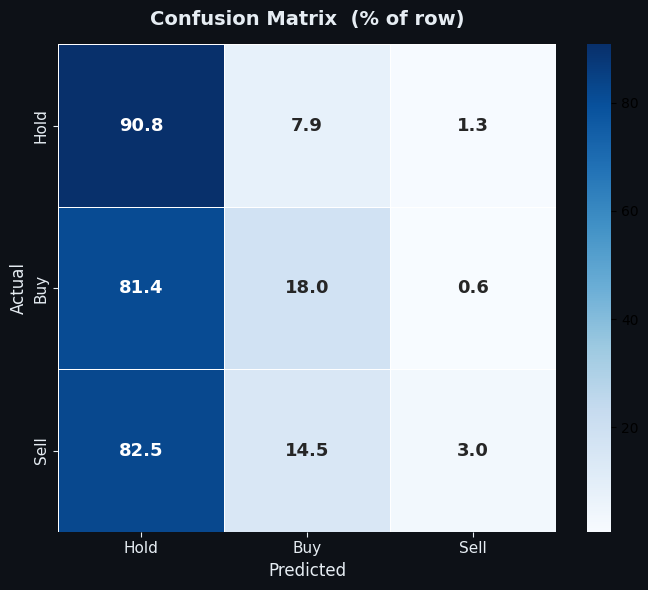

 Plot 1 saved → plot1_confusion_matrix.png


In [32]:
# ──────────────────────────────────────────────────────────────────────────────
# 8.3  PLOT 1 — Confusion Matrix
# ──────────────────────────────────────────────────────────────────────────────
cm      = confusion_matrix(all_y_true, all_y_pred)
cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig1, ax1 = plt.subplots(figsize=(7, 6))
fig1.patch.set_facecolor(DARK)
ax1.set_facecolor(PANEL)

sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax1, linewidths=0.5,
    annot_kws={'size': 13, 'weight': 'bold'}
)
ax1.set_xlabel('Predicted', color=TEXT, fontsize=12)
ax1.set_ylabel('Actual',    color=TEXT, fontsize=12)
ax1.set_title('Confusion Matrix  (% of row)', color=TEXT, fontsize=14, fontweight='bold', pad=14)
ax1.tick_params(colors=TEXT, labelsize=11)
for spine in ax1.spines.values():
    spine.set_edgecolor(GRID)

plt.tight_layout()
plt.savefig('plot1_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(" Plot 1 saved → plot1_confusion_matrix.png")


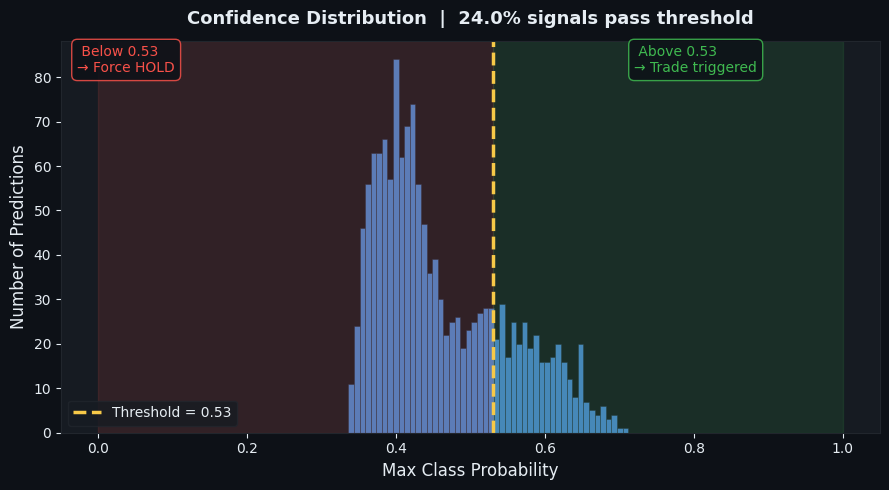

 Plot 2 saved → plot2_confidence_dist.png


In [33]:
# ──────────────────────────────────────────────────────────────────────────────
# 8.4  PLOT 2 — Confidence Distribution  (fee-trap threshold tuning)
# ──────────────────────────────────────────────────────────────────────────────
max_conf_all = all_y_proba.max(axis=1)
pct_tradeable = (max_conf_all >= CONFIDENCE_THRESHOLD).mean() * 100

fig2, ax2 = plt.subplots(figsize=(9, 5))
fig2.patch.set_facecolor(DARK)
ax2.set_facecolor(PANEL)

ax2.hist(max_conf_all, bins=50, color=ACC, alpha=0.75, edgecolor=GRID, linewidth=0.4)
ax2.axvspan(0,                    CONFIDENCE_THRESHOLD, alpha=0.12, color=SELL)
ax2.axvspan(CONFIDENCE_THRESHOLD, 1.0,                  alpha=0.12, color=BUY)
ax2.axvline(CONFIDENCE_THRESHOLD, color='#f7c948', linewidth=2.5,
            linestyle='--', label=f'Threshold = {CONFIDENCE_THRESHOLD}')

ax2.set_xlabel('Max Class Probability',        color=TEXT, fontsize=12)
ax2.set_ylabel('Number of Predictions',        color=TEXT, fontsize=12)
ax2.set_title(f'Confidence Distribution  |  {pct_tradeable:.1f}% signals pass threshold',
              color=TEXT, fontsize=13, fontweight='bold', pad=12)
ax2.tick_params(colors=TEXT, labelsize=10)
for spine in ax2.spines.values():
    spine.set_edgecolor(GRID)

ax2.text(0.02, 0.92, f' Below {CONFIDENCE_THRESHOLD}\n→ Force HOLD',
         transform=ax2.transAxes, color=SELL, fontsize=10,
         bbox=dict(boxstyle='round,pad=0.4', facecolor=DARK, edgecolor=SELL, alpha=0.85))
ax2.text(0.70, 0.92, f' Above {CONFIDENCE_THRESHOLD}\n→ Trade triggered',
         transform=ax2.transAxes, color=BUY, fontsize=10,
         bbox=dict(boxstyle='round,pad=0.4', facecolor=DARK, edgecolor=BUY, alpha=0.85))

legend = ax2.legend(fontsize=10, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)
plt.tight_layout()
plt.savefig('plot2_confidence_dist.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(" Plot 2 saved → plot2_confidence_dist.png")

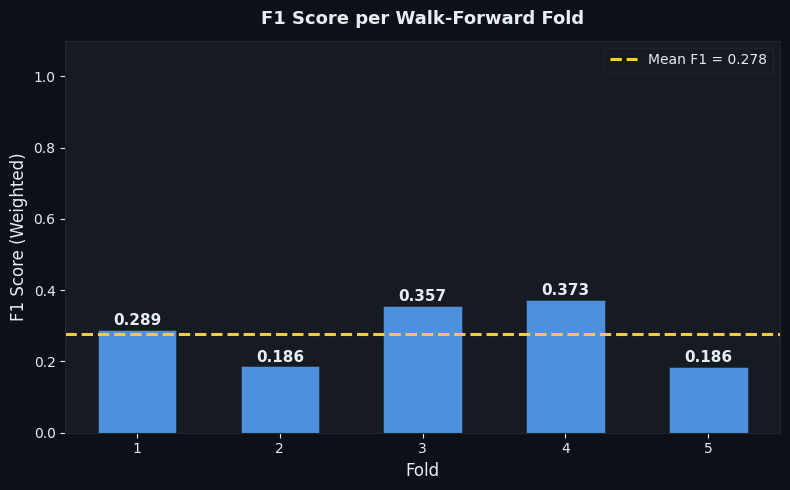

 Plot 3 saved → plot3_fold_f1.png


In [34]:
# ──────────────────────────────────────────────────────────────────────────────
# 8.5  PLOT 3 — Walk-Forward F1 per Fold
# ──────────────────────────────────────────────────────────────────────────────
folds   = results_df['fold'].values
f1_vals = results_df['f1_weighted'].values

fig3, ax3 = plt.subplots(figsize=(8, 5))
fig3.patch.set_facecolor(DARK)
ax3.set_facecolor(PANEL)

bars = ax3.bar(folds, f1_vals, color=ACC, alpha=0.85, edgecolor=GRID, linewidth=0.5, width=0.55)
ax3.axhline(f1_vals.mean(), color='#f7c948', linewidth=2.2,
            linestyle='--', label=f'Mean F1 = {f1_vals.mean():.3f}')

for bar, val in zip(bars, f1_vals):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.004,
             f'{val:.3f}', ha='center', va='bottom', color=TEXT, fontsize=11, fontweight='bold')

ax3.set_xlabel('Fold',                  color=TEXT, fontsize=12)
ax3.set_ylabel('F1 Score (Weighted)',   color=TEXT, fontsize=12)
ax3.set_title('F1 Score per Walk-Forward Fold', color=TEXT, fontsize=13, fontweight='bold', pad=12)
ax3.set_xticks(folds)
ax3.set_ylim(0, 1.1)
ax3.tick_params(colors=TEXT, labelsize=10)
for spine in ax3.spines.values():
    spine.set_edgecolor(GRID)

ax3.legend(fontsize=10, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)
plt.tight_layout()
plt.savefig('plot3_fold_f1.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(" Plot 3 saved → plot3_fold_f1.png")

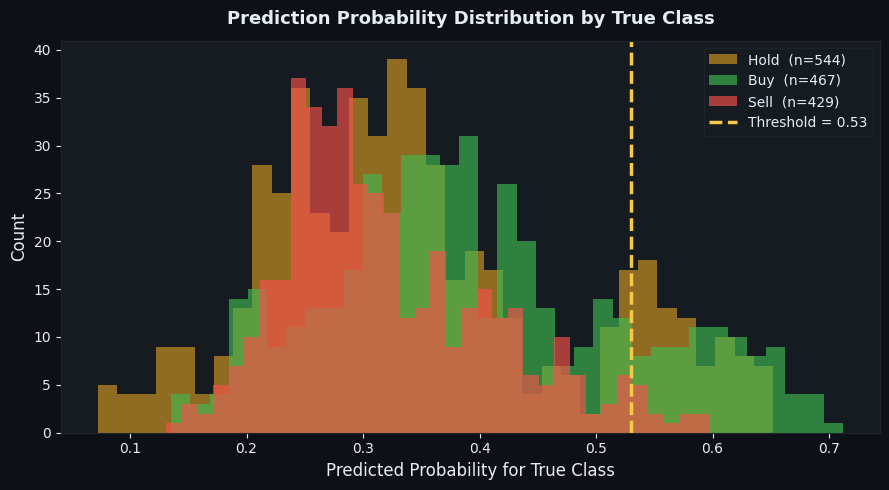

 Plot 4 saved → plot4_prob_by_class.png

 All 4 plots rendered and saved successfully.


In [35]:
# ──────────────────────────────────────────────────────────────────────────────
# 8.6  PLOT 4 — Predicted Probability Distribution by True Class
# ──────────────────────────────────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(9, 5))
fig4.patch.set_facecolor(DARK)
ax4.set_facecolor(PANEL)

colors_per_class = [HOLD, BUY, SELL]
for cls_idx, (cls_name, clr) in enumerate(zip(CLASS_NAMES, colors_per_class)):
    mask = all_y_true == cls_idx
    if mask.sum() > 0:
        probs = all_y_proba[mask, cls_idx]
        ax4.hist(probs, bins=35, alpha=0.65, color=clr,
                 label=f'{cls_name}  (n={mask.sum()})', edgecolor='none')

ax4.axvline(CONFIDENCE_THRESHOLD, color='#f7c948', linewidth=2.5,
            linestyle='--', label=f'Threshold = {CONFIDENCE_THRESHOLD}')
ax4.set_xlabel('Predicted Probability for True Class', color=TEXT, fontsize=12)
ax4.set_ylabel('Count',                                color=TEXT, fontsize=12)
ax4.set_title('Prediction Probability Distribution by True Class',
              color=TEXT, fontsize=13, fontweight='bold', pad=12)
ax4.tick_params(colors=TEXT, labelsize=10)
for spine in ax4.spines.values():
    spine.set_edgecolor(GRID)

ax4.legend(fontsize=10, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)
plt.tight_layout()
plt.savefig('plot4_prob_by_class.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(" Plot 4 saved → plot4_prob_by_class.png")

print("\n All 4 plots rendered and saved successfully.")

# CELL 9 — Final Model Training on Full Dataset + Threshold Analysis

- After cross-validation gives us confidence in the architecture, we train
- a final model on ALL available data (minus a held-out test tail) for
- deployment. This model is what you'd use in live inference.

- We also sweep confidence thresholds from 0.45 to 0.75 to show how
- precision and trade frequency trade off — helping you decide whether
- to keep 0.53 or adjust it for this new architecture.

In [37]:
# ── 9.1  Train/Test Split (last 20% = test, chronological)
TEST_FRAC    = 0.20
split_idx    = int(len(X_seq) * (1 - TEST_FRAC))

X_seq_final_tr  = X_seq[:split_idx]
X_stat_final_tr = X_static[:split_idx]
y_final_tr      = y[:split_idx]

X_seq_test       = X_seq[split_idx:]
X_stat_test      = X_static[split_idx:]
y_test           = y[split_idx:]

print(f"Final train : {len(y_final_tr)} samples")
print(f"Hold-out test: {len(y_test)} samples (never seen during CV)")

Final train : 1384 samples
Hold-out test: 346 samples (never seen during CV)


In [38]:
# ── 9.2  Scale & Augment final training set
n_final, sl, nf = X_seq_final_tr.shape
ts_scaler_final     = StandardScaler()
static_scaler_final = StandardScaler()

ts_scaler_final.fit(X_seq_final_tr.reshape(-1, nf))
static_scaler_final.fit(X_stat_final_tr)

X_seq_final_sc  = ts_scaler_final.transform(
    X_seq_final_tr.reshape(-1, nf)
).reshape(n_final, sl, nf).astype(np.float32)
X_stat_final_sc = static_scaler_final.transform(X_stat_final_tr).astype(np.float32)

# Apply augmentation to final training set
final_aug = DataAugmenter(aug_factor=1)
X_seq_aug_f, X_stat_aug_f, y_aug_f = final_aug.augment(
    X_seq_final_sc, X_stat_final_sc, y_final_tr
)

# Scale test set using FINAL TRAIN scaler only
n_test = len(y_test)
X_seq_test_sc  = ts_scaler_final.transform(
    X_seq_test.reshape(-1, nf)
).reshape(n_test, sl, nf).astype(np.float32)
X_stat_test_sc = static_scaler_final.transform(X_stat_test).astype(np.float32)

In [39]:
# ── 9.3  Train final model
final_model = build_model(
    seq_len=SEQUENCE_LEN,
    n_ts_features=len(TS_FEATURES),
    n_static_features=len(STATIC_FEATURES)
)

cw_final = compute_class_weight('balanced', classes=np.unique(y_aug_f), y=y_aug_f)
cw_final_dict = dict(enumerate(cw_final))

print("\nTraining final deployment model...")
final_history = final_model.fit(
    [X_seq_aug_f, X_stat_aug_f], y_aug_f,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=cw_final_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=0)
    ],
    verbose=1
)


Training final deployment model...
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 329ms/step - accuracy: 0.3931 - loss: 1.1814 - val_accuracy: 0.5632 - val_loss: 0.9707 - learning_rate: 0.0010
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 310ms/step - accuracy: 0.4425 - loss: 1.0764 - val_accuracy: 0.5487 - val_loss: 0.9828 - learning_rate: 0.0010
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 310ms/step - accuracy: 0.4596 - loss: 1.0464 - val_accuracy: 0.5487 - val_loss: 0.9697 - learning_rate: 0.0010
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 306ms/step - accuracy: 0.4719 - loss: 1.0244 - val_accuracy: 0.5487 - val_loss: 0.9526 - learning_rate: 0.0010
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 300ms/step - accuracy: 0.4805 - loss: 1.0223 - val_accuracy: 0.5523 - val_loss: 0.9559 - learning_rate: 0.0010
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 300ms/step - accuracy: 0.4921 - loss: 1.0068 - val_accuracy: 0.5379 - val_loss: 0.9496 - learning_rate: 0.0010
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 318m

In [40]:
# ── 9.4  Threshold Sweep
test_proba = final_model.predict([X_seq_test_sc, X_stat_test_sc], verbose=0)
test_conf  = test_proba.max(axis=1)
test_pred_raw = np.argmax(test_proba, axis=1)

print("\n" + "═" * 65)
print("  CONFIDENCE THRESHOLD SWEEP  (hold-out test set)")
print("═" * 65)
print(f"  {'Threshold':>10} | {'Trades%':>8} | {'Precision':>10} | {'F1 (W)':>8}")
print("  " + "-" * 55)

thresholds = np.arange(0.40, 0.76, 0.03)
for thr in thresholds:
    mask   = test_conf >= thr
    if mask.sum() == 0:
        continue
    y_thr  = np.where(mask, test_pred_raw, 0)
    pct    = mask.mean() * 100
    prec   = precision_score(y_test, y_thr, average='weighted', zero_division=0)
    f1_thr = f1_score(y_test, y_thr, average='weighted', zero_division=0)
    marker = " ◀ current" if abs(thr - CONFIDENCE_THRESHOLD) < 0.015 else ""
    print(f"  {thr:>10.2f} | {pct:>7.1f}% | {prec:>10.4f} | {f1_thr:>8.4f}{marker}")

print("\n Use this table to decide if 0.53 remains optimal for the new model.")



═════════════════════════════════════════════════════════════════
  CONFIDENCE THRESHOLD SWEEP  (hold-out test set)
═════════════════════════════════════════════════════════════════
   Threshold |  Trades% |  Precision |   F1 (W)
  -------------------------------------------------------
        0.40 |    98.8% |     0.3710 |   0.2659
        0.43 |    98.6% |     0.3710 |   0.2659
        0.46 |    97.4% |     0.3537 |   0.2563
        0.49 |    94.2% |     0.3415 |   0.2514
        0.52 |    90.5% |     0.3554 |   0.2638 ◀ current
        0.55 |    86.7% |     0.3561 |   0.2618
        0.58 |    84.1% |     0.3570 |   0.2647
        0.61 |    82.1% |     0.3600 |   0.2679
        0.64 |    77.2% |     0.3598 |   0.2707
        0.67 |    73.1% |     0.3232 |   0.2518
        0.70 |    71.4% |     0.2844 |   0.2352
        0.73 |    68.2% |     0.2599 |   0.2265

 Use this table to decide if 0.53 remains optimal for the new model.


In [41]:
# ── 9.5  Save final model
final_model.save('lstm_attention_fusion_model.keras')
print("\n Final model saved → lstm_attention_fusion_model.keras")
print("   Load with: model = keras.models.load_model('lstm_attention_fusion_model.keras')")



 Final model saved → lstm_attention_fusion_model.keras
   Load with: model = keras.models.load_model('lstm_attention_fusion_model.keras')


# CELL 10 — Live Inference Helper

- This function is what you'd call in your live trading execution loop.
- It mirrors the Fusion strategy's confidence gate before sending an order.

In [42]:
def predict_signal(ohlcv_df, sentiment_score, onchain_norm, fear_greed_norm,
                   model, ts_scaler, static_scaler,
                   ts_cols=TS_FEATURES, static_cols=STATIC_FEATURES,
                   seq_len=SEQUENCE_LEN, threshold=CONFIDENCE_THRESHOLD):
    """
    Generate a trading signal for the latest candle.

    Parameters
    ----------
    ohlcv_df        : pd.DataFrame — must contain at least `seq_len` rows
                      with all TS_FEATURES columns already computed
    sentiment_score : float — your NLP model output  [-1, 1]
    onchain_norm    : float — normalised on-chain metric [0, 1]
    fear_greed_norm : float — normalised fear/greed index [0, 1]
    model           : trained keras.Model
    ts_scaler       : fitted StandardScaler for time-series features
    static_scaler   : fitted StandardScaler for static features
    threshold       : float — confidence gate (default 0.53)

    Returns
    -------
    dict with keys: signal, confidence, probabilities, action
    """
    # Build sequence from latest `seq_len` candles
    ts_vals = ohlcv_df[ts_cols].values[-seq_len:]
    ts_scaled = ts_scaler.transform(ts_vals).astype(np.float32)
    X_seq_live = ts_scaled[np.newaxis, :, :]         # shape (1, seq_len, n_feat)

    # Static features
    static_raw = np.array([[sentiment_score, onchain_norm, fear_greed_norm]])
    X_static_live = static_scaler.transform(static_raw).astype(np.float32)

    # Inference
    proba      = model.predict([X_seq_live, X_static_live], verbose=0)[0]
    signal_idx = int(np.argmax(proba))
    confidence = float(proba[signal_idx])

    # Apply confidence gate — same as existing Fusion 0.53 threshold
    if confidence >= threshold:
        action = CLASS_NAMES[signal_idx]
    else:
        action = 'HOLD (low confidence)'

    return {
        'signal'       : CLASS_NAMES[signal_idx],
        'confidence'   : round(confidence, 4),
        'probabilities': {cls: round(float(p), 4)
                          for cls, p in zip(CLASS_NAMES, proba)},
        'action'       : action,
        'passes_threshold': confidence >= threshold
    }
# ── Demo call with the most recent test candles
sample_result = predict_signal(
    ohlcv_df=df.iloc[-(SEQUENCE_LEN + 5):],
    sentiment_score=0.25,
    onchain_norm=0.6,
    fear_greed_norm=0.55,
    model=final_model,
    ts_scaler=ts_scaler_final,
    static_scaler=static_scaler_final
)

print("\n" + "═" * 50)
print("  LIVE INFERENCE DEMO")
print("═" * 50)
for k, v in sample_result.items():
    print(f"  {k:<22}: {v}")


══════════════════════════════════════════════════
  LIVE INFERENCE DEMO
══════════════════════════════════════════════════
  signal                : Sell
  confidence            : 0.9514
  probabilities         : {'Hold': 0.0357, 'Buy': 0.013, 'Sell': 0.9514}
  action                : Sell
  passes_threshold      : True
